# This notebook shows how to compute the ground-state energy, band structure and density of states of bulk silicon with elkpy
### Import the necessary libraries

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

from elkpy.structure import Structure

### Create the structure and solve the Kohn-Sham ground state
$$ \Big[-\tfrac12\nabla^2+v_{\rm eff}(\mathbf r)\Big]\psi_{i\mathbf k}(\mathbf r)=\epsilon_i(\mathbf k)\,\psi_{i\mathbf k}(\mathbf r). $$
$v_{\rm eff}=v_{\rm ext}+v_H[n]+v_{xc}[n]$ is solved self-consistently in the density $n(\mathbf r)=\sum_{i\mathbf k}^{\rm occ}|\psi_{i\mathbf k}(\mathbf r)|^2$, in Elk's full-potential LAPW basis (atomic-like functions inside muffin-tin spheres, plane waves in the interstitial).

In [2]:
SI_AVEC = [(5.13, 5.13, 0.00), (5.13, 0.00, 5.13), (0.00, 5.13, 5.13)]
SI_SPECIES = {"Si": [(0.0, 0.0, 0.0), (0.25, 0.25, 0.25)]}

structure = Structure(SI_AVEC, SI_SPECIES)
calc = structure.get_calculation("_scratch/si", xc="PW", ngridk=(2, 2, 2))
e = calc.get_energy() # Hartree
print(e)

-577.98351598716


### Band structure
Bloch's theorem, $\psi_{i\mathbf k}(\mathbf r+\mathbf R)=e^{i\mathbf k\cdot\mathbf R}\psi_{i\mathbf k}(\mathbf r)$, gives the dispersion $\epsilon_i(\mathbf k)$ along a path of high-symmetry points.

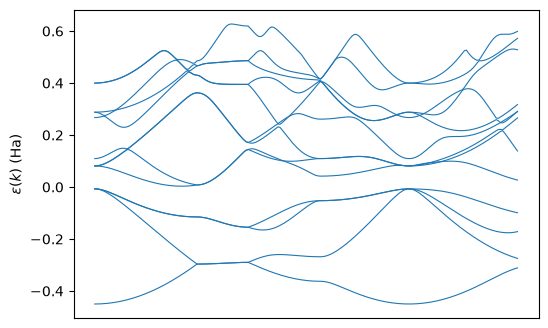

In [3]:
distances, energies = calc.get_bands(kpath="GXWLGK", npoints=200) # epsilon_i(k)

fig, ax = plt.subplots(figsize=(6, 4))
for band in energies:
    ax.plot(distances, band, color="tab:blue", lw=0.8)
ax.set_ylabel(r"$\epsilon(k)$ (Ha)")
ax.set_xticks([])
plt.show()

### Density of states
$$ g(\epsilon)=\sum_i\int_{\rm BZ}\frac{d^3k}{(2\pi)^3}\;\delta(\epsilon-\epsilon_i(\mathbf k)) $$

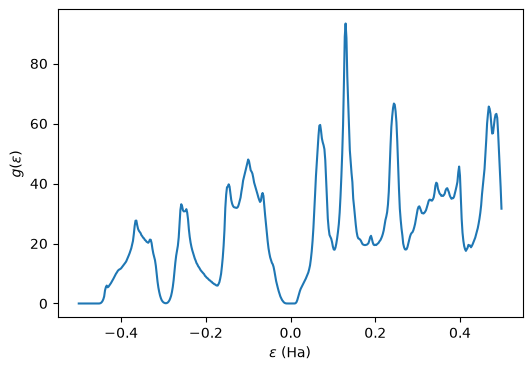

In [4]:
energies_dos, dos = calc.get_dos(ngridk=(6, 6, 6)) # denser k-mesh for this call only

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(energies_dos, dos)
ax.set_xlabel(r"$\epsilon$ (Ha)")
ax.set_ylabel(r"$g(\epsilon)$")
plt.show()